# Comparación de cuantización para un modelo fijo

Este notebook compara **tres cuantizaciones** del modelo escogido, usando:

- **`avg_pqs_modified`** desde el CSV de sintaxis
- **`bertscore_f1`** desde el JSON de resultados
- **`rougeL`** desde el JSON de resultados
- **`avg_time_per_sample`** desde el JSON de resultados

Está preparado para el mismo formato de archivos que vienes usando:

- JSON con estructura `results -> [ { model_name, bertscore_f1, rougeL, avg_time_per_sample, ... } ]`
- CSV resumen con columnas como `model_name, avg_pqs_modified, ...`

El notebook **solo extrae los datos de** `Qwen2.5-7B-Instruct`, aunque el JSON y el CSV contengan otros modelos.


In [11]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# -----------------------------
# Configuración principal
# -----------------------------
MODEL_NAME = "Qwen2.5-7B-Instruct"

BASE_DIR = Path(".") 

# Edita estas rutas según tus archivos reales
QUANT_CONFIG = {
    "4-bit": { 
        "json": BASE_DIR / "cuantizacion4-qwen-2" / "cuantizacion4-2.json",
        "csv":  BASE_DIR / "cuantizacion4-qwen-2" / "cuantizacion4-2_batfish_verified_summary.csv",
    },
    "8-bit": {
        "json": BASE_DIR / "cuantizacion8-qwen" / "cuantizacion8.json",
        "csv":  BASE_DIR / "cuantizacion8-qwen" / "cuantizacion8_batfish_verified_summary.csv",
    },
    "FP16": {
        "json": BASE_DIR / "confew" / "confew.json",
        "csv":  BASE_DIR / "confew" / "confew_batfish_verified_summary.csv",
    },
}

# Orden visual de las cuantizaciones
QUANT_ORDER = ["4-bit", "8-bit", "FP16"]

# Nombre del archivo consolidado opcional
OUTPUT_TABLE = Path("qwen_quantization_comparison_summary.csv")


In [12]:
# Verificación rápida de archivos
for quant, paths in QUANT_CONFIG.items():
    print(f"\n[{quant}]")
    print(" JSON:", paths["json"], "->", paths["json"].exists())
    print(" CSV: ", paths["csv"],  "->", paths["csv"].exists())



[4-bit]
 JSON: cuantizacion4-qwen-2\cuantizacion4-2.json -> True
 CSV:  cuantizacion4-qwen-2\cuantizacion4-2_batfish_verified_summary.csv -> True

[8-bit]
 JSON: cuantizacion8-qwen\cuantizacion8.json -> True
 CSV:  cuantizacion8-qwen\cuantizacion8_batfish_verified_summary.csv -> True

[FP16]
 JSON: confew\confew.json -> True
 CSV:  confew\confew_batfish_verified_summary.csv -> True


## Funciones auxiliares

In [13]:
def load_model_metrics_from_json(json_path: Path, model_name: str) -> dict:
    """
    Lee el JSON de resultados y devuelve las métricas del modelo indicado.
    """
    if not json_path.exists():
        raise FileNotFoundError(f"No existe el archivo JSON: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, dict) or "results" not in data:
        raise ValueError(f"Formato JSON no válido en {json_path}. Se esperaba una clave 'results'.")

    results = data["results"]
    if not isinstance(results, list):
        raise ValueError(f"La clave 'results' no es una lista en {json_path}.")

    for row in results:
        if str(row.get("model_name", "")).strip() == model_name.strip():
            return {
                "model_name": row.get("model_name"),
                "params": row.get("params"),
                "samples_evaluated": row.get("samples_evaluated"),
                "bertscore_f1": row.get("bertscore_f1"),
                "rougeL": row.get("rougeL"),
                "avg_time_per_sample": row.get("avg_time_per_sample"),
                "total_time_s": row.get("total_time_s"),
            }

    available = [str(r.get("model_name")) for r in results if "model_name" in r]
    raise ValueError(
        f"No se encontró el modelo '{model_name}' en {json_path}. "
        f"Modelos disponibles: {available}"
    )


def load_model_syntax_from_csv(csv_path: Path, model_name: str) -> dict:
    """
    Lee el CSV resumen de Batfish y devuelve la fila del modelo indicado.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"No existe el archivo CSV: {csv_path}")

    df = pd.read_csv(csv_path)

    required_cols = {
        "model_name",
        "avg_pqs_modified",
        "total_modified_files",
        "total_passed",
        "total_partially_parsed",
        "total_failed",
        "total_unknown",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(
            f"Al CSV {csv_path} le faltan columnas requeridas: {sorted(missing)}"
        )

    row = df.loc[df["model_name"].astype(str).str.strip() == model_name.strip()]
    if row.empty:
        available = df["model_name"].astype(str).tolist()
        raise ValueError(
            f"No se encontró el modelo '{model_name}' en {csv_path}. "
            f"Modelos disponibles: {available}"
        )

    row = row.iloc[0]
    return {
        "avg_pqs_modified": row["avg_pqs_modified"],
        "total_modified_files": row["total_modified_files"],
        "total_passed": row["total_passed"],
        "total_partially_parsed": row["total_partially_parsed"],
        "total_failed": row["total_failed"],
        "total_unknown": row["total_unknown"],
    }


def build_comparison_table(config: dict, model_name: str) -> pd.DataFrame:
    rows = []
    for quant_label, paths in config.items():
        json_metrics = load_model_metrics_from_json(paths["json"], model_name)
        csv_metrics = load_model_syntax_from_csv(paths["csv"], model_name)

        row = {
            "quantization": quant_label,
            **json_metrics,
            **csv_metrics,
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    order_map = {name: i for i, name in enumerate(QUANT_ORDER)}
    df["__order"] = df["quantization"].map(order_map).fillna(999)
    df = df.sort_values("__order").drop(columns="__order").reset_index(drop=True)

    numeric_cols = [
        "bertscore_f1",
        "rougeL",
        "avg_time_per_sample",
        "total_time_s",
        "avg_pqs_modified",
        "total_modified_files",
        "total_passed",
        "total_partially_parsed",
        "total_failed",
        "total_unknown",
        "samples_evaluated",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


## Cargar y revisar datos

In [14]:
df = build_comparison_table(QUANT_CONFIG, MODEL_NAME)
df


,quantization,model_name,params,samples_evaluated,bertscore_f1,rougeL,avg_time_per_sample,total_time_s,avg_pqs_modified,total_modified_files,total_passed,total_partially_parsed,total_failed,total_unknown
0,4-bit,Qwen2.5-7B-Instruct,7B,100,0.9847,0.8737,3.8080,380.80,0.90500,153,131,22,0,0
1,8-bit,Qwen2.5-7B-Instruct,7B,100,0.9882,0.8885,10.1065,1010.65,0.91000,156,139,17,0,0
2,FP16,Qwen2.5-7B-Instruct,7B,100,0.9885,0.8903,4.0948,409.48,0.91575,154,135,19,0,0


In [15]:
# Guardar tabla consolidada opcional
df.to_csv(OUTPUT_TABLE, index=False, encoding="utf-8")
print(f"Tabla guardada en: {OUTPUT_TABLE.resolve()}")


Tabla guardada en: C:\Users\juan\Documents\Miguel\tesis\System\Orchestrator-mcpServers\Orchestrator\sintaxys\qwen_quantization_comparison_summary.csv


## Resumen compacto para presentación

Esta tabla deja visibles las métricas principales para decidir entre cuantizaciones.


In [16]:
summary_cols = [
    "quantization",
    "avg_pqs_modified",
    "bertscore_f1",
    "rougeL",
    "avg_time_per_sample",
    "total_modified_files",
    "total_passed",
    "total_partially_parsed",
]
df[summary_cols]


,quantization,avg_pqs_modified,bertscore_f1,rougeL,avg_time_per_sample,total_modified_files,total_passed,total_partially_parsed
0,4-bit,0.90500,0.9847,0.8737,3.8080,153,131,22
1,8-bit,0.91000,0.9882,0.8885,10.1065,156,139,17
2,FP16,0.91575,0.9885,0.8903,4.0948,154,135,19


## Gráfica 1: barras agrupadas de calidad

Incluye las tres métricas comparables en escala 0–1:

- `avg_pqs_modified`
- `bertscore_f1`
- `rougeL`


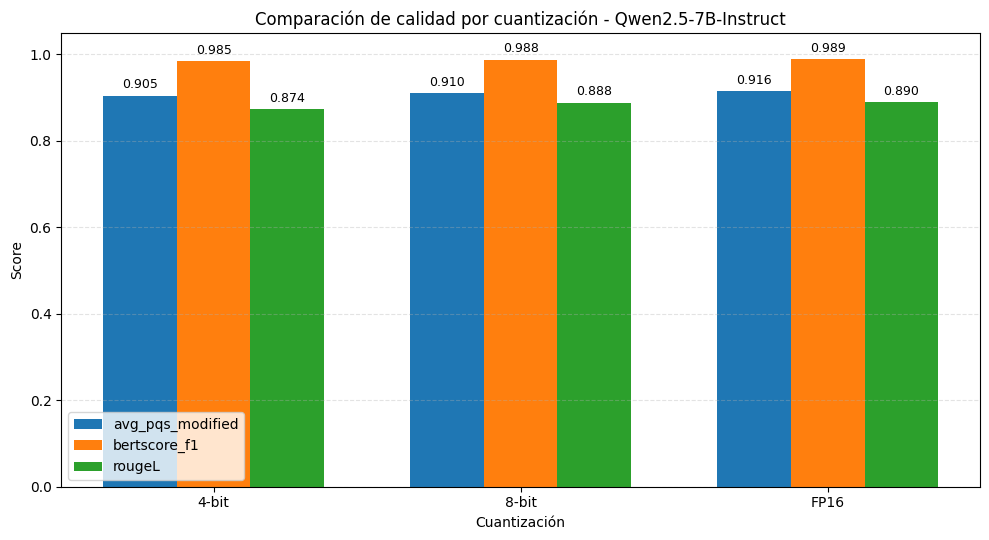

In [17]:
plot_df = df.copy()

metrics = ["avg_pqs_modified", "bertscore_f1", "rougeL"]
metric_labels = ["avg_pqs_modified", "bertscore_f1", "rougeL"]

x = range(len(plot_df))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    positions = [p + (i - 1) * width for p in x]
    bars = ax.bar(positions, plot_df[metric], width=width, label=label)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_title(f"Comparación de calidad por cuantización - {MODEL_NAME}")
ax.set_xlabel("Cuantización")
ax.set_ylabel("Score")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df["quantization"])
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


## Gráfica 2: tiempo promedio por muestra

Se grafica aparte porque está en una escala distinta.


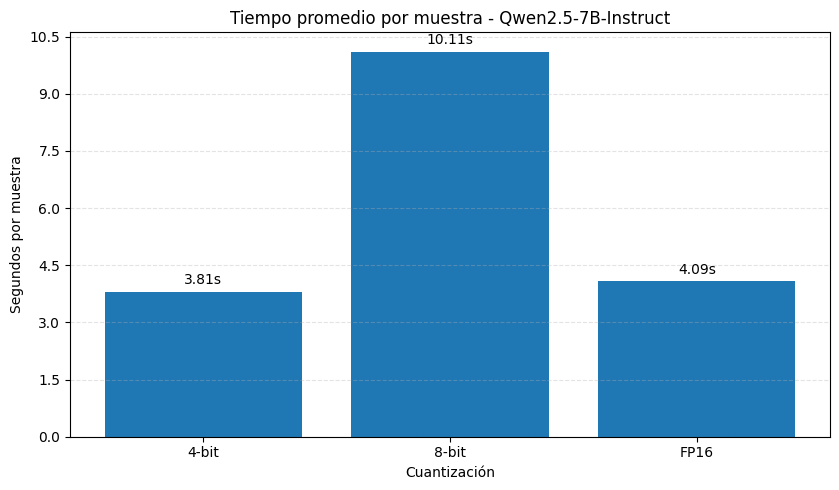

In [18]:
time_df = df.copy()

fig, ax = plt.subplots(figsize=(8.5, 5))

bars = ax.bar(time_df["quantization"], time_df["avg_time_per_sample"])

for bar in bars:
    h = bar.get_height()
    ax.annotate(
        f"{h:.2f}s",
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title(f"Tiempo promedio por muestra - {MODEL_NAME}")
ax.set_xlabel("Cuantización")
ax.set_ylabel("Segundos por muestra")
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()


## Interpretación automática básica

La lógica siguiente prioriza:

1. mayor `avg_pqs_modified`
2. mayor `bertscore_f1`
3. menor `avg_time_per_sample`


In [19]:
ranking_df = df.sort_values(
    by=["avg_pqs_modified", "bertscore_f1", "avg_time_per_sample"],
    ascending=[False, False, True]
).reset_index(drop=True)

ranking_df[[
    "quantization",
    "avg_pqs_modified",
    "bertscore_f1",
    "rougeL",
    "avg_time_per_sample",
    "total_modified_files"
]]


,quantization,avg_pqs_modified,bertscore_f1,rougeL,avg_time_per_sample,total_modified_files
0,FP16,0.91575,0.9885,0.8903,4.0948,154
1,8-bit,0.91000,0.9882,0.8885,10.1065,156
2,4-bit,0.90500,0.9847,0.8737,3.8080,153


In [20]:
best = ranking_df.iloc[0]

print("Mejor cuantización según la regla definida:")
print(f"- Cuantización: {best['quantization']}")
print(f"- avg_pqs_modified: {best['avg_pqs_modified']:.3f}")
print(f"- bertscore_f1: {best['bertscore_f1']:.3f}")
print(f"- rougeL: {best['rougeL']:.3f}")
print(f"- avg_time_per_sample: {best['avg_time_per_sample']:.2f}s")
print(f"- total_modified_files: {int(best['total_modified_files'])}")


Mejor cuantización según la regla definida:
- Cuantización: FP16
- avg_pqs_modified: 0.916
- bertscore_f1: 0.989
- rougeL: 0.890
- avg_time_per_sample: 4.09s
- total_modified_files: 154


## Nota

Solo necesitas cambiar la celda de `QUANT_CONFIG` con tus rutas reales.
El resto del notebook funciona mientras se mantenga el mismo formato de JSON y CSV.
